In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


In [3]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [4]:
df['Car'] = df['Car'].fillna(0)

# remove duplicated rows
df = df.drop_duplicates()

# Fix the Date data type mismatch so it plots chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [5]:
print("Check")
print("Number of properties with 0 Landsize left:", (df['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of properties with 0 Landsize left: 1939
Number of properties with 0 Building area left: 17
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

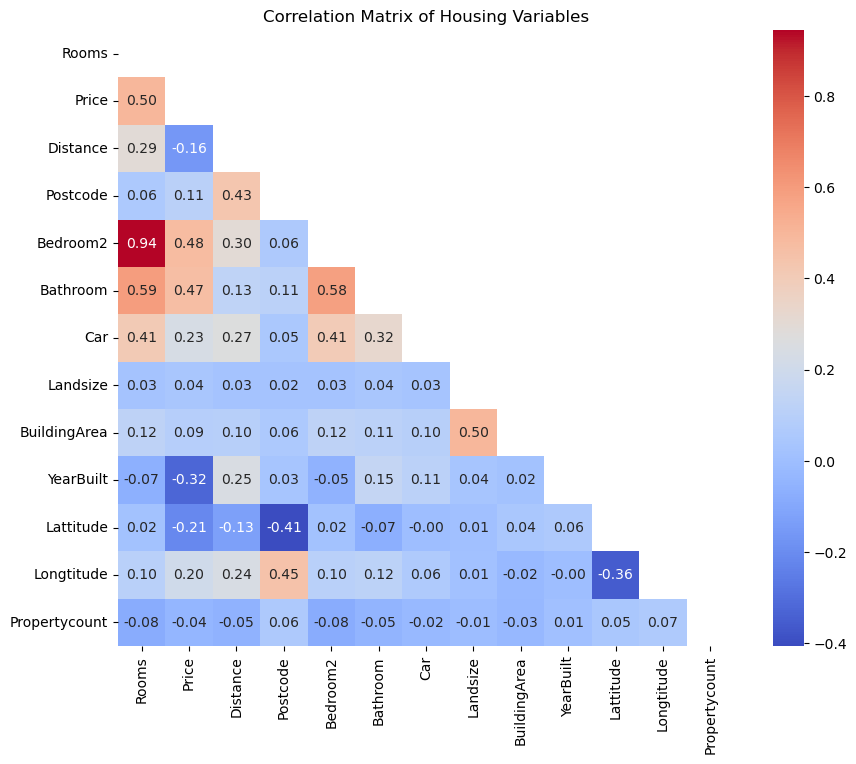

In [6]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [7]:
# remove columns that we do not need
df = df.drop(
    columns=[
        "BuildingArea",
        "SellerG",
        "Date",
        "Postcode",
        "Address",
        "Propertycount",
        "Method",
        "YearBuilt",
        "Suburb",
        "CouncilArea",
        "Bedroom2",],
    errors="ignore",
)

# creates new features for analysing
df = df.assign(
    Price_per_Landsize = lambda x: x['Price'] / x['Landsize'],
    Distance_Category = pd.cut(
        df['Distance'],
        bins=[0, 10, 20, 30, float('inf')],
        labels=['Near', 'Middle', 'Far', 'Outer']
    )
)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

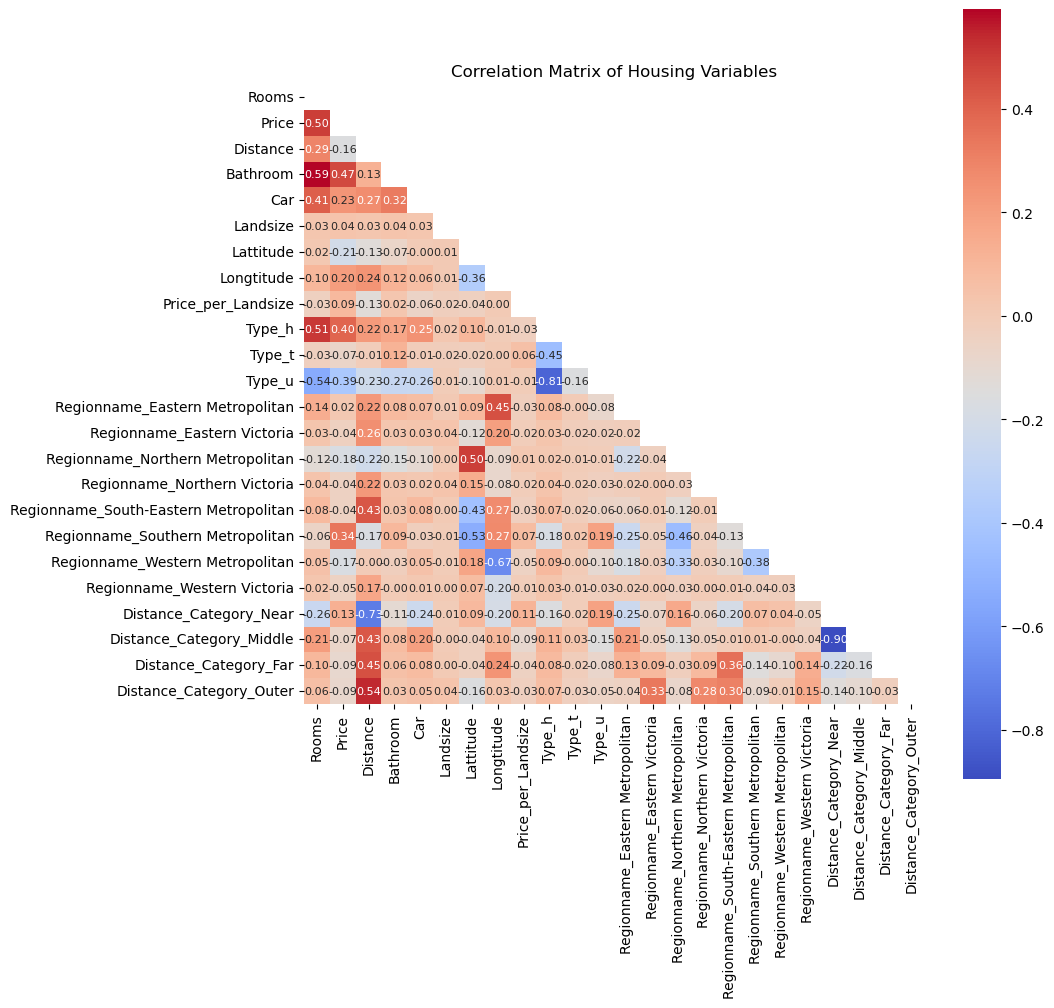

In [8]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname", "Distance_Category"])

# Now calculate correlation on the newly encoded dataset
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 8})

plt.title("Correlation Matrix of Housing Variables")

In [9]:
# Clean Landsize
Q1_land = df["Landsize"].quantile(0.25)
Q3_land = df["Landsize"].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df = df[(df["Landsize"] >= lower_land) & (df["Landsize"] <= upper_land)]

# Clean Price
Q1_price = df["Price"].quantile(0.25)
Q3_price = df["Price"].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price
df = df[(df["Price"] >= lower_price) & (df["Price"] <= upper_price)]

# Clean Price per landsize
Q1_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.25)
Q3_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.75)
IQR_Price_per_Landsize = Q3_Price_per_Landsize - Q1_Price_per_Landsize
lower_Price_per_Landsize = Q1_Price_per_Landsize - 1.5 * IQR_Price_per_Landsize
upper_Price_per_Landsize = Q3_Price_per_Landsize + 1.5 * IQR_Price_per_Landsize
df = df[(df["Price_per_Landsize"] >= lower_Price_per_Landsize) & (df["Price_per_Landsize"] <= upper_Price_per_Landsize)]


print("Total rows remaining:", len(df))

Total rows remaining: 10579


In [10]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

                   Missing Count  Percentage (%)
Distance_Category              1        0.009453


In [15]:
# remove the 1 missing value for Distance Category
df = df.dropna(subset=["Distance_Category"])
missing_count = df["Distance_Category"].isna().sum()

print(f"Missing values in Distance_category: {missing_count}")

Missing values in Distance_category: 0


The correlation matrix shows that housing price is most positively related to rooms, bedrooms, bathrooms and building area. Distance from the CBD has a negative relationship with price, suggesting that properties further from the CBD are generally cheaper, although the relationship is not very strong.

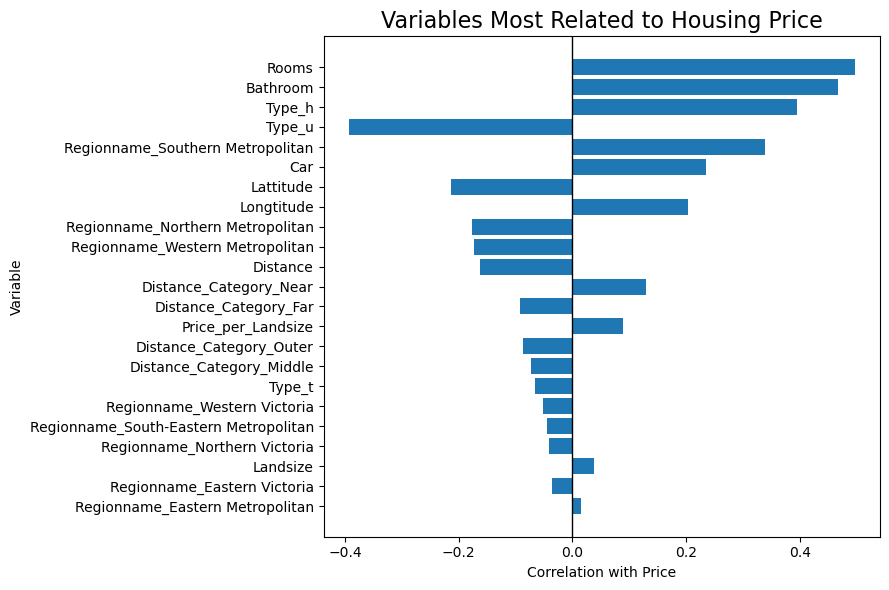

Correlation with Price:
Rooms                                    0.496634
Bathroom                                 0.467038
Type_h                                   0.395035
Type_u                                  -0.393378
Regionname_Southern Metropolitan         0.338032
Car                                      0.234825
Lattitude                               -0.212934
Longtitude                               0.203656
Regionname_Northern Metropolitan        -0.175933
Regionname_Western Metropolitan         -0.172367
Distance                                -0.162522
Distance_Category_Near                   0.130210
Distance_Category_Far                   -0.091897
Price_per_Landsize                       0.088396
Distance_Category_Outer                 -0.087141
Distance_Category_Middle                -0.073692
Type_t                                  -0.066377
Regionname_Western Victoria             -0.051555
Regionname_South-Eastern Metropolitan   -0.044231
Regionname_Northern Victor

In [25]:
price_corr = corr['Price'].drop('Price').sort_values(
    key=lambda x: abs(x),
    ascending=True
)

plt.figure(figsize=(9, 6))
plt.barh(price_corr.index, price_corr.values)

plt.axvline(0, color='black', linewidth=1)
plt.title('Variables Most Related to Housing Price', fontsize=16)
plt.xlabel('Correlation with Price')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

print("Correlation with Price:")
print(price_corr.sort_values(key=lambda x: abs(x), ascending=False))

The strongest positive relationships with price are rooms, bedrooms and bathrooms, indicating that larger properties are generally more expensive. Distance from the CBD has a negative correlation with price, while property count has very limited influence.

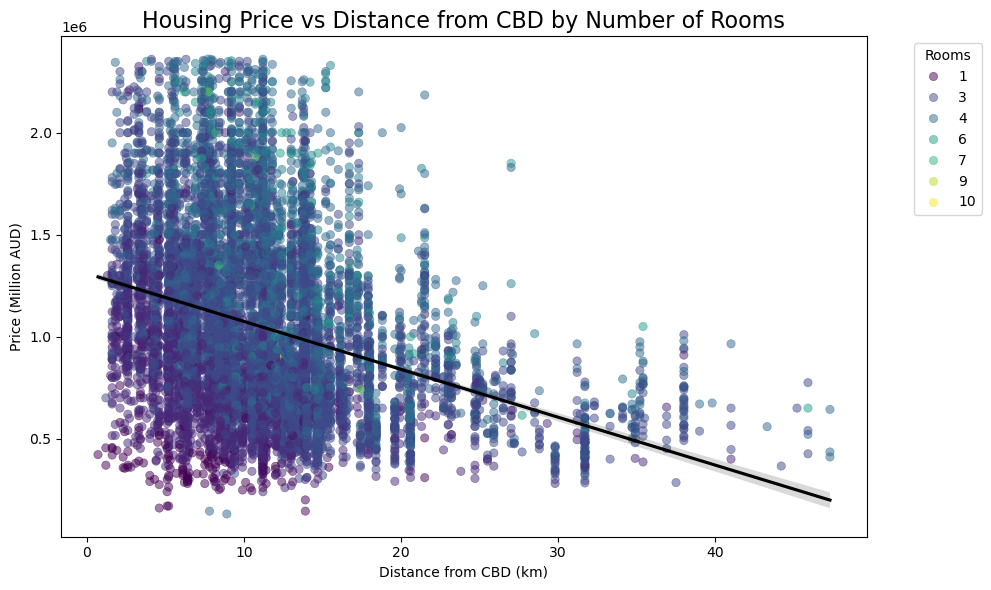

In [31]:
plt.figure(figsize=(10, 6))

# Plots every row in the dataset
sns.scatterplot(
    data=df,
    x='Distance',
    y='Price',
    hue='Rooms',
    palette='viridis',
    alpha=0.5,
    edgecolor=None
)

# Add trend line using the same y-variable
sns.regplot(
    data=df, 
    x='Distance', 
    y='Price',
    scatter=False,
    color='black'
)

plt.title('Housing Price vs Distance from CBD by Number of Rooms', fontsize=16)
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Price (Million AUD)')
plt.legend(title='Rooms', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


The scatter plot shows a general downward trend between distance from the CBD and housing price. Properties closer to the CBD tend to have higher prices, while prices become lower as distance increases. However, the spread of points also shows that rooms and other location factors still affect price.

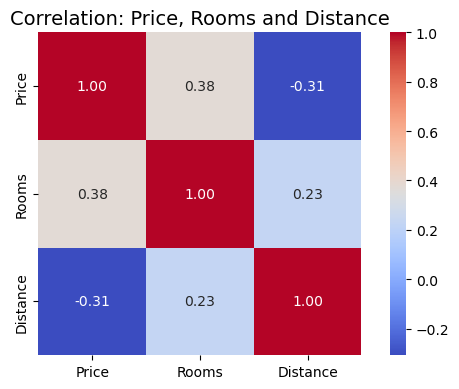

             Price     Rooms  Distance
Price     1.000000  0.375060 -0.308003
Rooms     0.375060  1.000000  0.228503
Distance -0.308003  0.228503  1.000000


In [33]:
q2_corr = df[['Price', 'Rooms', 'Distance']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    q2_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)

plt.title('Correlation: Price, Rooms and Distance', fontsize=14)
plt.tight_layout()
plt.show()

print(q2_corr)

Price is moderately correlated with rooms, while its relationship with distance is weaker and negative. This suggests that affordability is not only about location; larger properties further from the CBD may offer more space at lower prices.

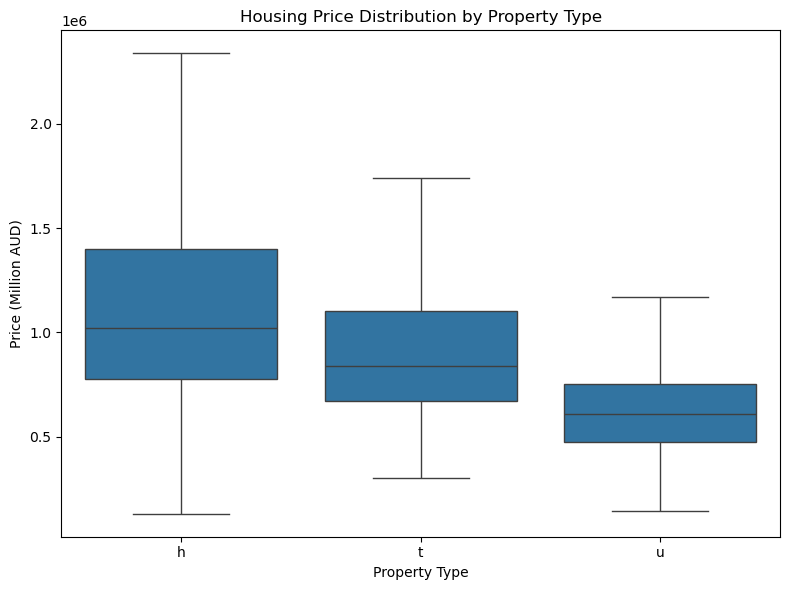

In [42]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data = df,
    x ='Type',
    y ='Price',
    showfliers=False
)

plt.title('Housing Price Distribution by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Price (Million AUD)')

plt.tight_layout()
plt.show()

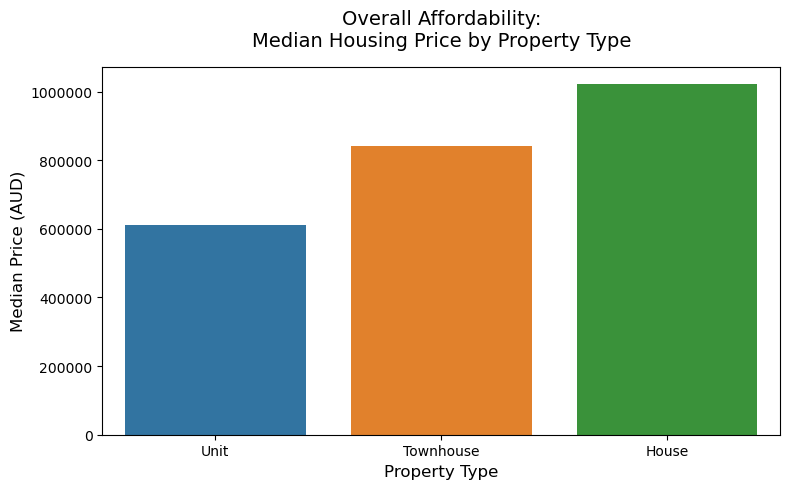

In [67]:
type_mapping = {'h': 'House', 't': 'Townhouse', 'u': 'Unit'}
df['Type_Label'] = df['Type'].map(type_mapping).fillna(df['Type'])
df['Price_per_Room'] = df['Price'] / df['Rooms']

# Generate summary data
type_summary = (
    df.groupby('Type_Label')
    .agg(
        Median_Price=('Price', 'median'),
        Price_per_Room=('Price_per_Room', 'median')
    )
    .reindex(['Unit', 'Townhouse', 'House'])
    .reset_index()
)

# Plot Chart 1: Overall Affordability
plt.figure(figsize=(8, 5))
sns.barplot(
    data=type_summary,
    x='Type_Label',
    y='Median_Price',
    hue='Type_Label',
    legend=False,
)
plt.title('Overall Affordability:\nMedian Housing Price by Property Type', fontsize=14, pad=15)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Median Price (AUD)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()


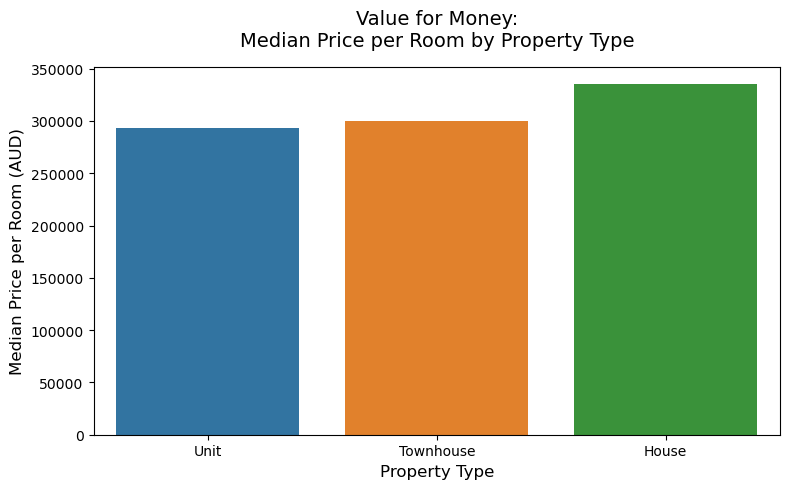

--- Property Summary Table ---
Type_Label  Median_Price  Price_per_Room
      Unit      611000.0   293333.333333
 Townhouse      840000.0   300000.000000
     House     1021000.0   335000.000000


In [66]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=type_summary,
    x='Type_Label',
    y='Price_per_Room',
    hue='Type_Label',
    legend=False,
)
plt.title('Value for Money:\nMedian Price per Room by Property Type', fontsize=14, pad=15)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Median Price per Room (AUD)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# Print the numbers below your charts
print("--- Property Summary Table ---")
print(type_summary.to_string(index=False))


Units have the lowest median price and a more compact price range, making them the most affordable option overall. Houses have the highest median price and the widest price spread, while townhouses sit between units and houses.

Units have the lowest median price at around $560,000, making them the most affordable option for young or first-home buyers. Houses have the highest median price at around $1.07 million, while townhouses provide a middle option.

When comparing median price per room, units still provide the lowest cost per room, while houses have the highest. This suggests that units may offer better value for money for first-home buyers with limited budgets.

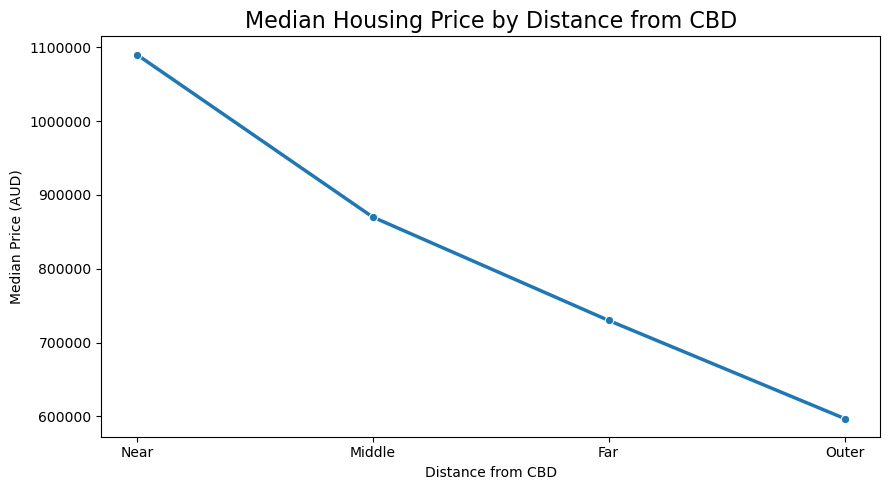

  Distance_Category  Median_Price  Average_Price  Count
0              Near     1090000.0   1.166423e+06   4907
1            Middle      870000.0   9.802817e+05   4986
2               Far      730000.0   7.649914e+05    493
3             Outer      597250.0   5.985727e+05    192


In [58]:
# ================================
# Q4: Does living further from CBD mean cheaper housing?
# Chart 1: Median price by distance band
# ================================

distance_summary = (
    df
    .dropna(subset=['Distance_Category'])
    .groupby('Distance_Category', observed=True)
    .agg(
        Median_Price=('Price', 'median'),
        Average_Price=('Price', 'mean'),
        Count=('Price', 'size')
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=distance_summary,
    x='Distance_Category',
    y='Median_Price',
    marker='o',
    linewidth=2.5
)

plt.title('Median Housing Price by Distance from CBD', fontsize=16)
plt.xlabel('Distance from CBD')
plt.ylabel('Median Price (AUD)')

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print(distance_summary)

Median housing price decreases steadily as distance from the CBD increases. Properties within 0–5 km have a median price of around $1.0 million, while properties over 30 km from the CBD have a median price of around $603,000. This suggests that living further from the CBD generally improves affordability.

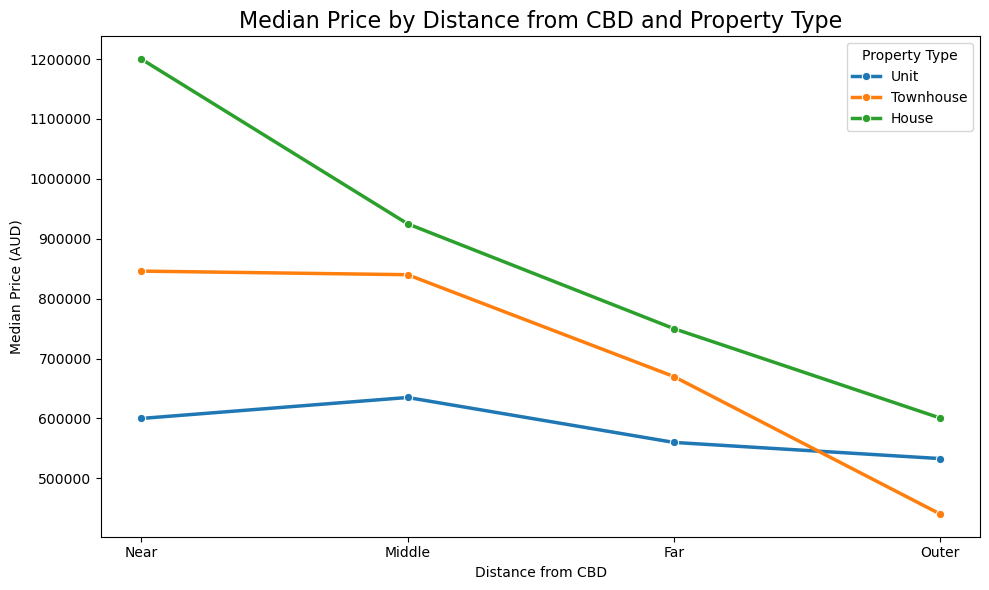

In [62]:
# ================================
# Q4: Distance from CBD by property type
# Chart 2: Median price by distance band and property type
# ================================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df.dropna(subset=['Distance_Category', 'Type_Label']),
    x='Distance_Category',
    y='Price',
    hue='Type_Label',
    hue_order=type_order,
    estimator='median',
    errorbar=None,
    marker='o',
    linewidth=2.5
)

plt.title('Median Price by Distance from CBD and Property Type', fontsize=16)
plt.xlabel('Distance from CBD')
plt.ylabel('Median Price (AUD)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title='Property Type')

plt.tight_layout()
plt.show()

Houses show the strongest price decline as distance from the CBD increases, while units remain the most affordable property type across most distance bands. This means distance improves affordability overall, but property type still plays an important role in determining housing value.